# 📊 Unemployment Analysis in India

## 🎯 Objective

 The objective of this project is to analyze unemployment trends in India using Python and Data Analytics techniques.

 The project focuses on:
 - State-wise unemployment analysis
 - Monthly unemployment trends
 - COVID-19 impact analysis
 - Data visualization and insights

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [7]:
df = pd.read_csv("../data/Unemployment_Rate_upto_11_2020.csv")

In [8]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 📌 Dataset Overview
Understanding the structure and information present in the dataset.

In [9]:
df.shape

(267, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [11]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [12]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [13]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [14]:
df.columns = df.columns.str.strip()

In [15]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [18]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [19]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

## 📈 State-wise Unemployment Analysis

In [20]:
state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

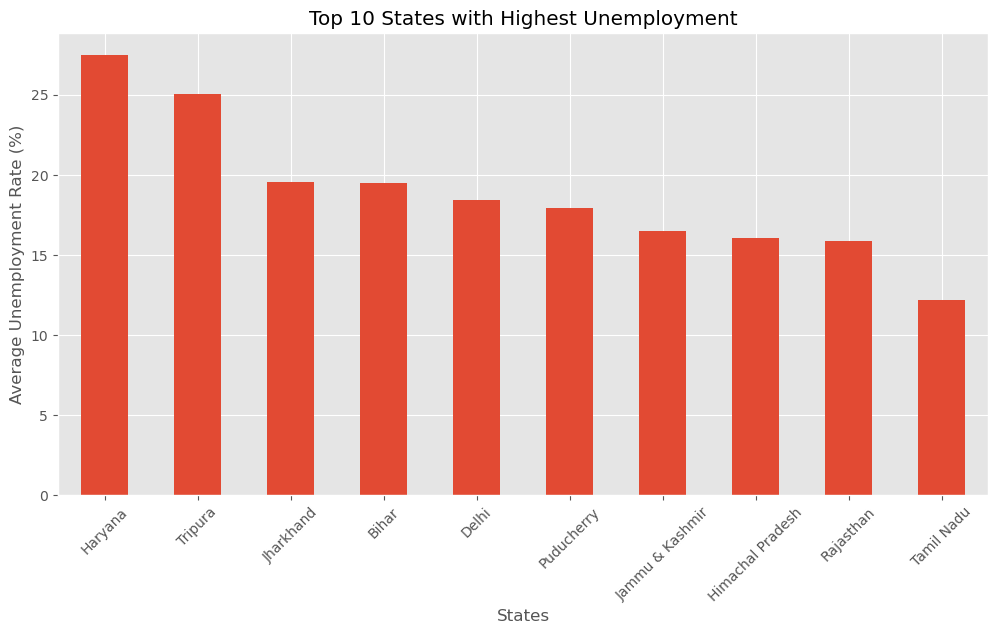

In [21]:
plt.figure(figsize=(12,6))

state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("States")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Insight:
States like Haryana and Tripura showed comparatively higher unemployment rates during the observed period.

## 📉 Monthly Unemployment Trend

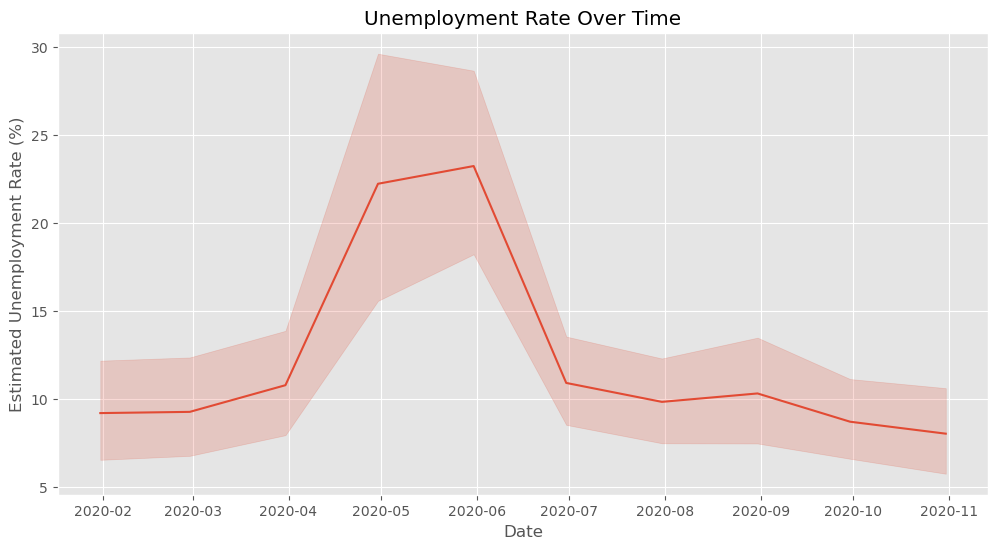

In [22]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment Rate Over Time")

plt.show()

## 🦠 COVID-19 Impact Analysis

## 🔥 Correlation Analysis

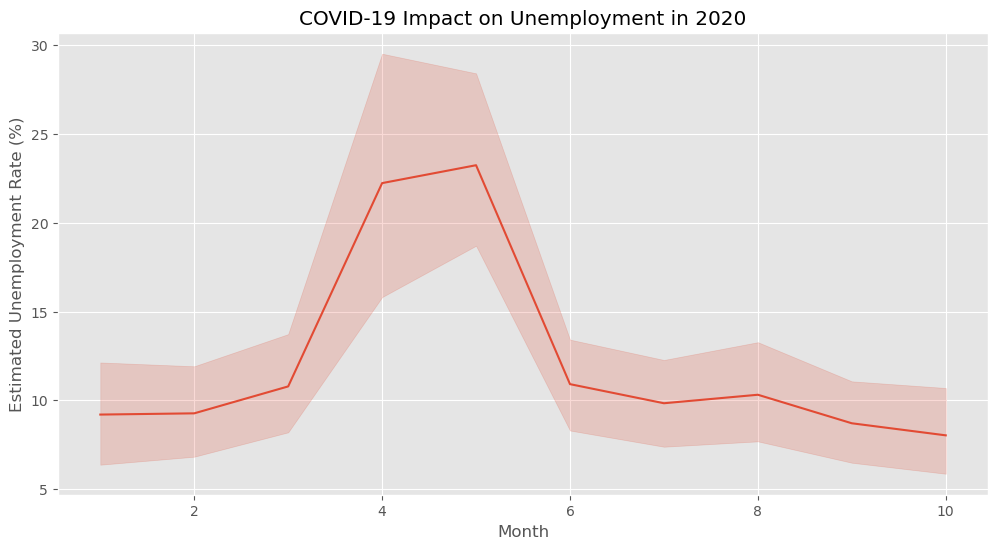

In [23]:
covid_period = df[df['Year'] == 2020]

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Month',
    y='Estimated Unemployment Rate (%)',
    data=covid_period
)

plt.title("COVID-19 Impact on Unemployment in 2020")

plt.show()

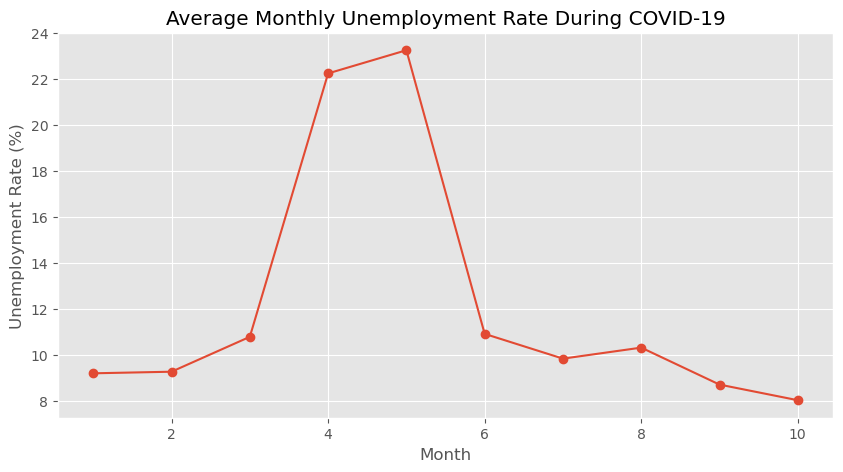

In [27]:
monthly_avg = covid_period.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(kind='line', marker='o')

plt.title("Average Monthly Unemployment Rate During COVID-19")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [28]:
df.drop(columns=['longitude', 'latitude', 'Region.1'], inplace=True)

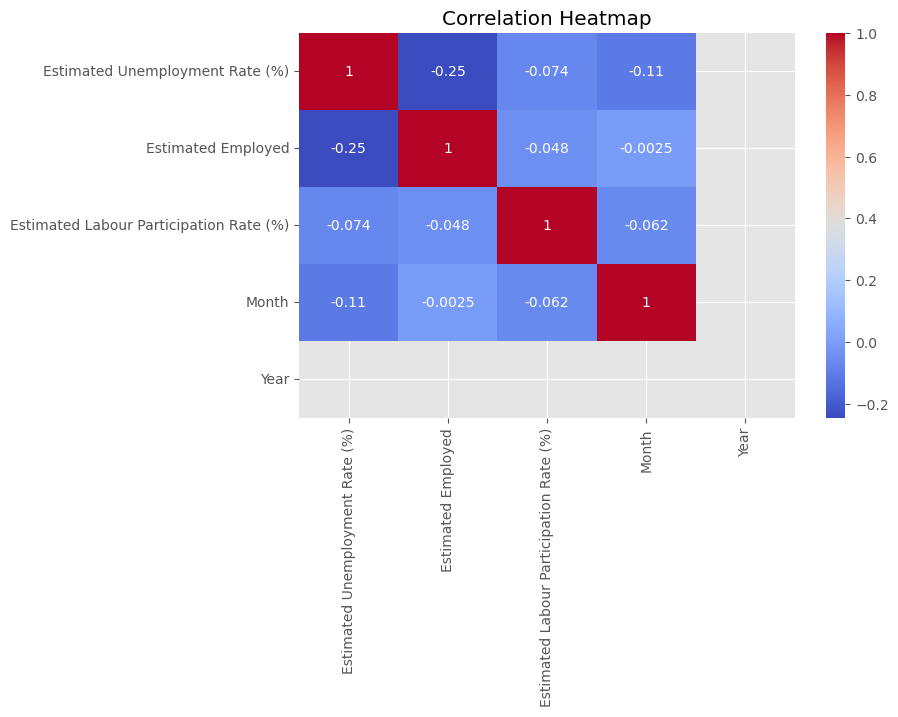

In [29]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

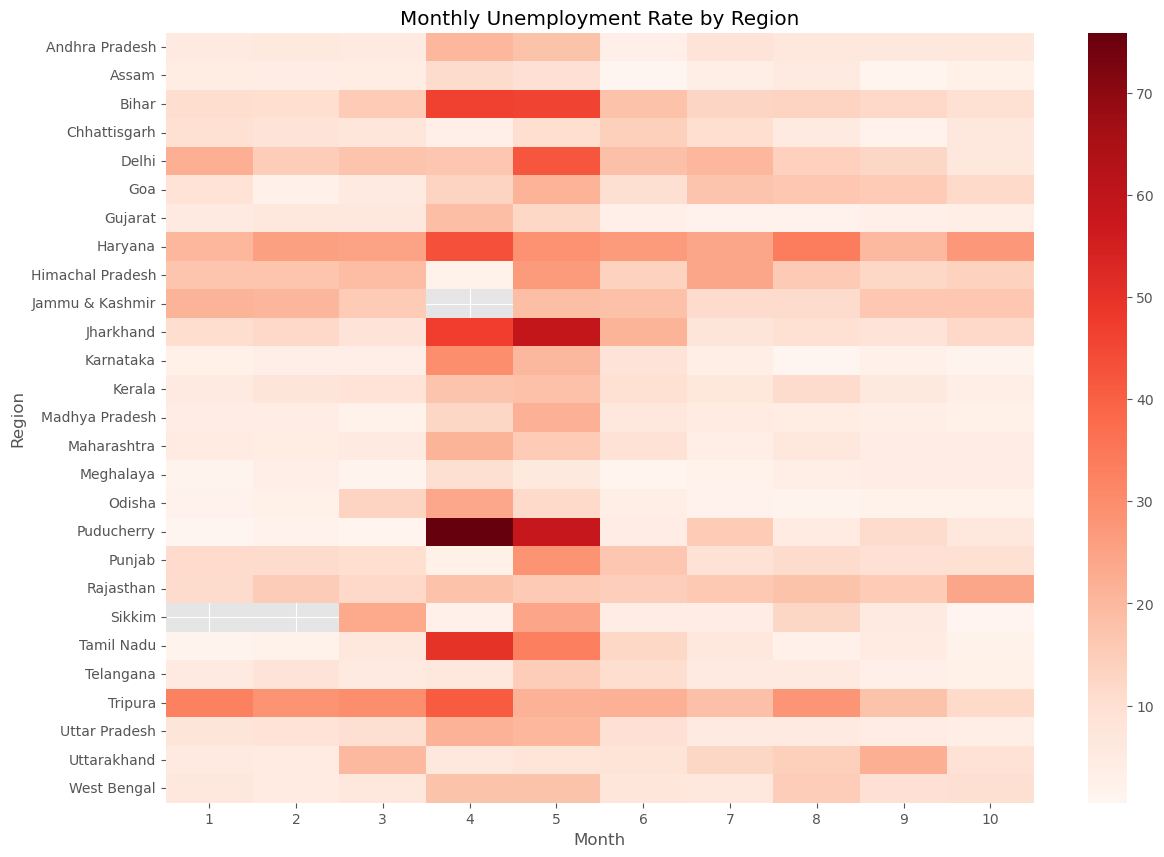

In [26]:
plt.figure(figsize=(14,10))

sns.heatmap(pivot, cmap='Reds')

plt.title("Monthly Unemployment Rate by Region")

plt.show()

# 📌 Key Insights

- Several Indian states experienced significantly high unemployment rates.
- Unemployment sharply increased during the COVID-19 lockdown period.
- Labour participation and employment trends were strongly correlated.
- Some states showed more economic stability compared to others.

# ✅ Conclusion

This project analyzed unemployment trends across India using data analytics and visualization techniques.

The analysis highlighted:
- state-wise unemployment differences,
- COVID-19 economic impact,
- and monthly unemployment trends.

The project demonstrates practical applications of:
- Python,
- Data Analysis,
- and Data Visualization.